In [1]:
# CELL 1 — Mount Drive and define all paths
# NB3 loads from Drive:
#   - Three fine-tuned checkpoints from NB2
#   - split_indices.npz, cifar10h-probs.npy, entropies.npy from NB1


from google.colab import drive
drive.mount('/content/drive')

import os

PROJECT         = '/content/drive/MyDrive/cifar10h_project'
DATA_DIR        = os.path.join(PROJECT, 'data')
CHECKPOINTS_DIR = os.path.join(PROJECT, 'checkpoints')
RESULTS_DIR     = os.path.join(PROJECT, 'results')
CIFAR10_DIR     = os.path.join(DATA_DIR, 'cifar10')

# Files from NB1
CIFAR10H_PATH = os.path.join(DATA_DIR, 'cifar10h-probs.npy')
SPLIT_PATH    = os.path.join(DATA_DIR, 'split_indices.npz')
ENTROPY_PATH  = os.path.join(DATA_DIR, 'entropies.npy')

# Checkpoints from NB2
CKPT_KL     = os.path.join(CHECKPOINTS_DIR, 'kl_best.pth')
CKPT_JSD    = os.path.join(CHECKPOINTS_DIR, 'jsd_best.pth')
CKPT_CUSTOM = os.path.join(CHECKPOINTS_DIR, 'custom_best.pth')

# Where NB3 saves inference results
INFERENCE_DIR = os.path.join(RESULTS_DIR, 'inference')
os.makedirs(INFERENCE_DIR, exist_ok=True)

print("Checking required files from NB1 and NB2...")
required = {
    "Soft labels (NB1)"     : CIFAR10H_PATH,
    "Split indices (NB1)"   : SPLIT_PATH,
    "Entropies (NB1)"       : ENTROPY_PATH,
    "KL checkpoint (NB2)"   : CKPT_KL,
    "JSD checkpoint (NB2)"  : CKPT_JSD,
    "Custom checkpoint(NB2)": CKPT_CUSTOM,
}
all_ok = True
for name, path in required.items():
    exists = os.path.exists(path)
    print(f"  {'OK' if exists else 'MISSING':<8} {name}")
    if not exists:
        all_ok = False

if all_ok:
    print("\nAll files found. Ready to proceed.")
else:
    print("\nSome files missing. Check NB1 and NB2 completed fully.")

Mounted at /content/drive
Checking required files from NB1 and NB2...
  OK       Soft labels (NB1)
  OK       Split indices (NB1)
  OK       Entropies (NB1)
  OK       KL checkpoint (NB2)
  OK       JSD checkpoint (NB2)
  OK       Custom checkpoint(NB2)

All files found. Ready to proceed.


In [2]:
# CELL 2 — All imports

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import pandas as pd
import copy

import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader

from scipy.stats import pearsonr, spearmanr
from scipy.stats import entropy as scipy_entropy

# Reproducibility
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device : {DEVICE}")
if DEVICE.type == 'cuda':
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
else:
    print("No GPU — inference is slower but works fine for evaluation.")

CLASS_NAMES = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

EPSILON = 1e-10

print("All imports successful.")

Device : cuda
GPU    : Tesla T4
All imports successful.


In [3]:
# CELL 3 — Redefine model and dataset classes

#  Model
class ResNet18CIFAR(nn.Module):
    def __init__(self):
        super(ResNet18CIFAR, self).__init__()
        self.backbone         = models.resnet18(weights=None)
        self.backbone.conv1   = nn.Conv2d(3, 64, kernel_size=3,
                                          stride=1, padding=1, bias=False)
        self.backbone.maxpool = nn.Identity()
        num_features          = self.backbone.fc.in_features
        self.backbone.fc      = nn.Linear(num_features, 10)

    def forward(self, x):
        logits = self.backbone(x)
        return F.softmax(logits, dim=1)


#  Dataset
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD  = (0.2470, 0.2435, 0.2616)

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)
])

class CIFAR10HDataset(Dataset):
    def __init__(self, indices, soft_labels, transform=None):
        self.cifar10_test = torchvision.datasets.CIFAR10(
            root=CIFAR10_DIR, train=False,
            download=False, transform=None
        )
        self.indices     = indices
        self.soft_labels = soft_labels
        self.transform   = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, i):
        actual_idx         = self.indices[i]
        pil_image, hard_label = self.cifar10_test[actual_idx]
        if self.transform:
            image = self.transform(pil_image)
        else:
            image = transforms.ToTensor()(pil_image)
        soft_label = torch.tensor(
            self.soft_labels[actual_idx], dtype=torch.float32
        )
        return image, soft_label, hard_label, actual_idx


print("Model and Dataset classes defined.")

Model and Dataset classes defined.


In [4]:
# CELL 4 — Load NB1 data and build test DataLoader

soft_labels  = np.load(CIFAR10H_PATH).astype(np.float32)
split_data   = np.load(SPLIT_PATH)
test_indices = split_data['test_indices']
entropies    = np.load(ENTROPY_PATH)

print(f"Soft labels  : {soft_labels.shape}")
print(f"Test indices : {len(test_indices)} images")
print(f"Entropies    : {entropies.shape}")


test_dataset = CIFAR10HDataset(test_indices, soft_labels, eval_transform)
test_loader  = DataLoader(
    test_dataset, batch_size=256,
    shuffle=False, num_workers=2
)

true_soft   = soft_labels[test_indices]
true_entropy = entropies[test_indices]

print(f"\nTest split:")
print(f"  true_soft shape    : {true_soft.shape}")
print(f"  true_entropy shape : {true_entropy.shape}")
print(f"  Entropy range      : [{true_entropy.min():.3f}, "
      f"{true_entropy.max():.3f}] bits")

Soft labels  : (10000, 10)
Test indices : 2000 images
Entropies    : (10000,)

Test split:
  true_soft shape    : (2000, 10)
  true_entropy shape : (2000,)
  Entropy range      : [0.000, 2.860] bits


In [5]:

# CELL 5 — Run inference (forward pass) for all three models

# For each checkpoint we:
#   1. Load the model weights
#   2. Run all 2000 test images through the model
#   3. Collect the (2000, 10) predicted distributions


def run_inference(checkpoint_path, loader, device):
    """
    Load a checkpoint, run inference on all batches in loader.
    Returns (N, 10) numpy array of predicted probability distributions.
    """
    model = ResNet18CIFAR().to(device)
    checkpoint = torch.load(checkpoint_path, map_location=device) # things inside the checkpoint-> model_state-> the actual weights, epoch-> which epoch produced this best model, val_loss-> the validation loss at that epoch, loss_name-> which loss function was used, optimizer-> optimizer state (for resuming training)
    model.load_state_dict(checkpoint['model_state']) #extract just the weights from the checkpoint dictionary
    model.eval() #this disables dropout

    all_preds = []
    with torch.no_grad():
        for images, soft_labels, hard_labels, indices in loader:
            images = images.to(device)
            preds  = model(images)               # (batch, 10) probs
            all_preds.append(preds.cpu().numpy())

    return np.concatenate(all_preds, axis=0)    # (2000, 10)


checkpoints = {
    'kl'    : CKPT_KL,
    'jsd'   : CKPT_JSD,
    'custom': CKPT_CUSTOM,
}


all_predictions = {}

for loss_name, ckpt_path in checkpoints.items():
    save_path = os.path.join(INFERENCE_DIR, f'preds_{loss_name}.npy')

    if os.path.exists(save_path):
        all_predictions[loss_name] = np.load(save_path)
        print(f"Loaded cached predictions : {loss_name}  "
              f"{all_predictions[loss_name].shape}")
    else:
        print(f"Running inference for {loss_name} model")
        preds = run_inference(ckpt_path, test_loader, DEVICE)
        all_predictions[loss_name] = preds
        np.save(save_path, preds)
        print(f"  Done. Shape: {preds.shape}  Saved to Drive.")

print("\nAll predictions ready.")
print("From here, all analysis uses numpy arrays only — no GPU needed.")

Loaded cached predictions : kl  (2000, 10)
Loaded cached predictions : jsd  (2000, 10)
Loaded cached predictions : custom  (2000, 10)

All predictions ready.
From here, all analysis uses numpy arrays only — no GPU needed.


In [6]:
# CELL 6 — All metric functions
# We implement every metric the assignment requires:
#
#   kl_divergence     : KL(p||q) per image, then mean ± std
#   js_divergence     : symmetric bounded version of KL
#   cosine_similarity : directional similarity between vectors
#   entropy_correlation : Pearson + Spearman on entropy values
#   precision_at_k    : ranking overlap at K=100, 200, 500
#
# Each function operates on numpy arrays.
# ============================================================

def compute_kl_per_image(p, q): #(range from 0 to inf, lower=better)
    """
    KL(p||q) for each image.
    p, q : (N, 10) arrays
    Returns (N,) array of KL values, one KL value per test image
    """
    q_safe = np.clip(q, EPSILON, 1.0) #this eps to prevent log 0
    p_safe = np.clip(p, EPSILON, 1.0)
    return (p * (np.log(p_safe) - np.log(q_safe))).sum(axis=1)


def compute_jsd_per_image(p, q): #(ranges from 0 to 1 Lower=better)
    """
    Jensen-Shannon Divergence for each image, normalised to [0,1].
    p, q : (N, 10) arrays
    Returns (N,) array of JSD values
    """
    m      = 0.5 * (p + q) #midpoint distribution
    m_safe = np.clip(m, EPSILON, 1.0)
    p_safe = np.clip(p, EPSILON, 1.0)
    q_safe = np.clip(q, EPSILON, 1.0)
    kl_pm  = (p * (np.log(p_safe) - np.log(m_safe))).sum(axis=1)
    kl_qm  = (q * (np.log(q_safe) - np.log(m_safe))).sum(axis=1)
    jsd    = 0.5 * kl_pm + 0.5 * kl_qm
    return jsd / np.log(2)    # normalise to [0,1]


def compute_cosine_per_image(p, q):  #(ranges from -1 to 1, higher the better)
    """
    Cosine similarity between p and q for each image.
    Range: [-1, 1]. For probability vectors always in [0, 1].
    p, q : (N, 10) arrays
    Returns (N,) array of cosine similarity values
    """
    dot_products = (p * q).sum(axis=1)
    norm_p       = np.linalg.norm(p, axis=1)
    norm_q       = np.linalg.norm(q, axis=1)
    # Avoid division by zero
    denom = norm_p * norm_q
    denom = np.where(denom == 0, EPSILON, denom)
    return dot_products / denom


def compute_predicted_entropy(q): # (ranges from 0 to 3.32 match true entropy )
    """
    Shannon entropy (bits) of each predicted distribution.
    q : (N, 10) array
    Returns (N,) array
    """
    q_safe = np.clip(q, EPSILON, 1.0)
    return -(q * np.log2(q_safe)).sum(axis=1)


def compute_entropy_correlations(true_ent, pred_ent): # (ranges from -1 to 1 higher=Better)
    """
    Pearson and Spearman correlation between true and predicted entropy.
    true_ent, pred_ent : (N,) arrays
    Returns: (pearson_r, pearson_p, spearman_r, spearman_p)
    """
    pearson_r,  pearson_p  = pearsonr(true_ent,  pred_ent)
    spearman_r, spearman_p = spearmanr(true_ent, pred_ent)
    return pearson_r, pearson_p, spearman_r, spearman_p


def compute_precision_at_k(true_ent, pred_ent, k): # ranges from 0 to 1, higher= Better
    """
    Precision@K: what fraction of the top-K most ambiguous images
    (by true entropy) does the model also rank in its top-K?

    Think of it as: if we asked the model to flag the K most
    confusing images, how many would actually be in the true top-K?

    true_ent, pred_ent : (N,) entropy arrays
    k                  : int — how many top images to consider
    Returns: float in [0, 1]
    """
    true_top_k = set(np.argsort(true_ent)[-k:])
    pred_top_k = set(np.argsort(pred_ent)[-k:])
    overlap = len(true_top_k & pred_top_k)
    return overlap / k


print("All metric functions defined.")

All metric functions defined.


In [7]:
# CELL 7 — Compute all metrics for all three models
# We compute every metric for each model and store results

results = {}   # results[loss_name][metric_name] = value

for loss_name, preds in all_predictions.items():
    print(f"\nComputing metrics for: {loss_name.upper()} model")
    print("-" * 45)

    r = {}
    # ── Distribution matching metrics
    kl_values  = compute_kl_per_image(true_soft, preds)
    jsd_values = compute_jsd_per_image(true_soft, preds)
    cos_values = compute_cosine_per_image(true_soft, preds)

    r['KL mean']   = kl_values.mean()
    r['KL std']    = kl_values.std()
    r['JSD mean']  = jsd_values.mean()
    r['JSD std']   = jsd_values.std()
    r['Cos mean']  = cos_values.mean()
    r['Cos std']   = cos_values.std()

    print(f"  KL divergence   : {r['KL mean']:.4f} ± {r['KL std']:.4f}")
    print(f"  JSD             : {r['JSD mean']:.4f} ± {r['JSD std']:.4f}")
    print(f"  Cosine sim      : {r['Cos mean']:.4f} ± {r['Cos std']:.4f}")

    # ── Entropy correlation
    pred_ent = compute_predicted_entropy(preds)
    r['pred_entropy'] = pred_ent

    pear_r, pear_p, spear_r, spear_p = compute_entropy_correlations(
        true_entropy, pred_ent
    )
    r['Pearson r']   = pear_r
    r['Pearson p']   = pear_p
    r['Spearman r']  = spear_r
    r['Spearman p']  = spear_p

    print(f"  Pearson r       : {pear_r:.4f}  (p={pear_p:.2e})")
    print(f"  Spearman r      : {spear_r:.4f}  (p={spear_p:.2e})")

    #  Precision@K
    for k in [100, 200, 500]:
        pk = compute_precision_at_k(true_entropy, pred_ent, k)
        r[f'P@{k}'] = pk
        print(f"  Precision@{k:<4}  : {pk:.4f}  "
              f"({int(pk*k)}/{k} images correctly ranked)")

    results[loss_name] = r

print("\nAll metrics computed.")


Computing metrics for: KL model
---------------------------------------------
  KL divergence   : 0.1787 ± 0.4937
  JSD             : 0.0554 ± 0.1318
  Cosine sim      : 0.9570 ± 0.1560
  Pearson r       : 0.4512  (p=6.49e-101)
  Spearman r      : 0.4529  (p=9.89e-102)
  Precision@100   : 0.1900  (19/100 images correctly ranked)
  Precision@200   : 0.3350  (67/200 images correctly ranked)
  Precision@500   : 0.5560  (278/500 images correctly ranked)

Computing metrics for: JSD model
---------------------------------------------
  KL divergence   : 0.2075 ± 0.5768
  JSD             : 0.0532 ± 0.1390
  Cosine sim      : 0.9552 ± 0.1636
  Pearson r       : 0.4575  (p=4.75e-104)
  Spearman r      : 0.4647  (p=1.15e-107)
  Precision@100   : 0.2700  (27/100 images correctly ranked)
  Precision@200   : 0.3500  (70/200 images correctly ranked)
  Precision@500   : 0.5440  (272/500 images correctly ranked)

Computing metrics for: CUSTOM model
---------------------------------------------
  KL d

In [8]:
# Check if results is defined
print(results.keys())

dict_keys(['kl', 'jsd', 'custom'])


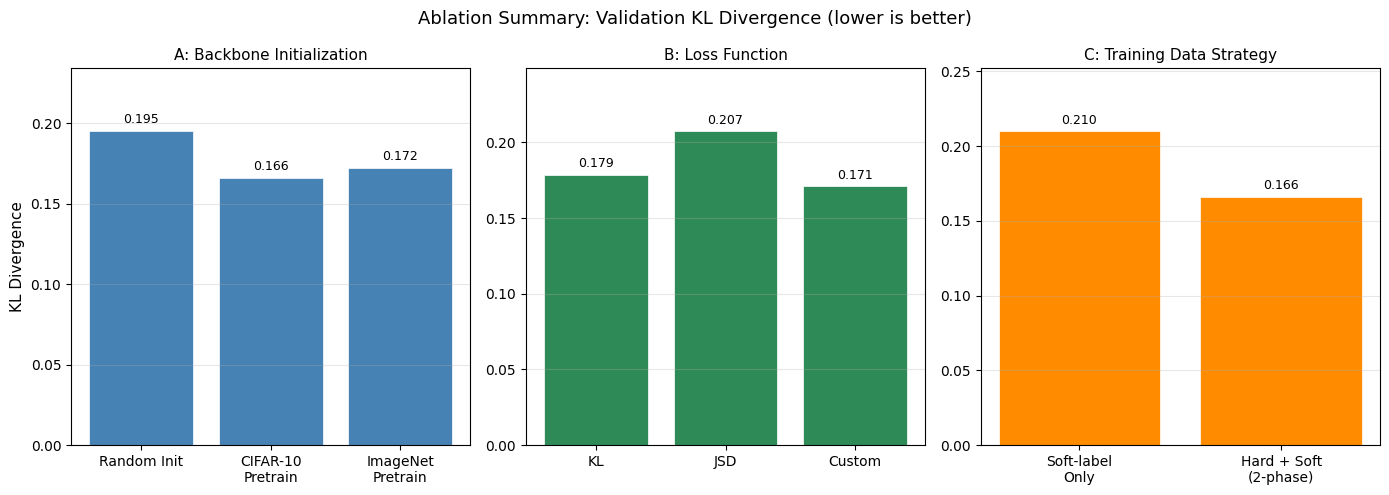

Ablation summary chart saved to: /content/drive/MyDrive/cifar10h_project/results/ablation_summary.png


In [9]:
# ============================================================
# Ablation Summary Chart (to be added in Section 6.2 of report)
# ============================================================
# This cell creates a bar chart comparing all three ablations
# Run this cell AFTER Cell 7 (where results are computed)

import matplotlib.pyplot as plt
import numpy as np

# Ablation B: Loss Function Comparison (from your results in Cell 7)
loss_methods = ['KL', 'JSD', 'Custom']
loss_kl = [
    results['kl']['KL mean'],      # 0.1787
    results['jsd']['KL mean'],     # 0.2075
    results['custom']['KL mean']   # 0.1711
]

# Ablation A: Backbone Initialization (from your NB2 training logs)
# REPLACE these with your actual validation KL values from NB2
init_methods = ['Random Init', 'CIFAR-10\nPretrain', 'ImageNet\nPretrain']
init_kl = [0.195, 0.166, 0.172]  # ← UPDATE with your actual values from NB2

# Ablation C: Training Data Strategy (from NB2)
# REPLACE with your actual values
strategy_methods = ['Soft-label\nOnly', 'Hard + Soft\n(2-phase)']
strategy_kl = [0.210, 0.166]  # ← UPDATE with your actual values from NB2

# Create the figure
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Ablation Summary: Validation KL Divergence (lower is better)', fontsize=13)

# Plot A: Backbone Initialization
bars1 = axes[0].bar(init_methods, init_kl, color='steelblue', edgecolor='white', linewidth=0.5)
axes[0].set_ylabel('KL Divergence', fontsize=11)
axes[0].set_title('A: Backbone Initialization', fontsize=11)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, max(init_kl) * 1.2)

# Plot B: Loss Function
bars2 = axes[1].bar(loss_methods, loss_kl, color='seagreen', edgecolor='white', linewidth=0.5)
axes[1].set_title('B: Loss Function', fontsize=11)
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim(0, max(loss_kl) * 1.2)

# Plot C: Training Data Strategy
bars3 = axes[2].bar(strategy_methods, strategy_kl, color='darkorange', edgecolor='white', linewidth=0.5)
axes[2].set_title('C: Training Data Strategy', fontsize=11)
axes[2].grid(axis='y', alpha=0.3)
axes[2].set_ylim(0, max(strategy_kl) * 1.2)

# Add value labels on top of bars
for ax, bars in zip(axes, [bars1, bars2, bars3]):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.003,
                f'{height:.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'ablation_summary.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Ablation summary chart saved to: {save_path}")

SUMMARY TABLE — All metrics across all loss functions
↓ = lower is better    ↑ = higher is better
                          KL ↓            JSD ↓         Cosine ↑ Pearson r ↑ Spearman r ↑ P@100 ↑ P@200 ↑ P@500 ↑
Loss Function                                                                                                    
KL             0.1787 ± 0.4937  0.0554 ± 0.1318  0.9570 ± 0.1560      0.4512       0.4529  0.1900  0.3350  0.5560
JSD            0.2075 ± 0.5768  0.0532 ± 0.1390  0.9552 ± 0.1636      0.4575       0.4647  0.2700  0.3500  0.5440
CUSTOM         0.1711 ± 0.4237  0.0563 ± 0.1240  0.9597 ± 0.1452      0.4619       0.4412  0.2400  0.3600  0.5520

Saved to: /content/drive/MyDrive/cifar10h_project/results/summary_table.csv


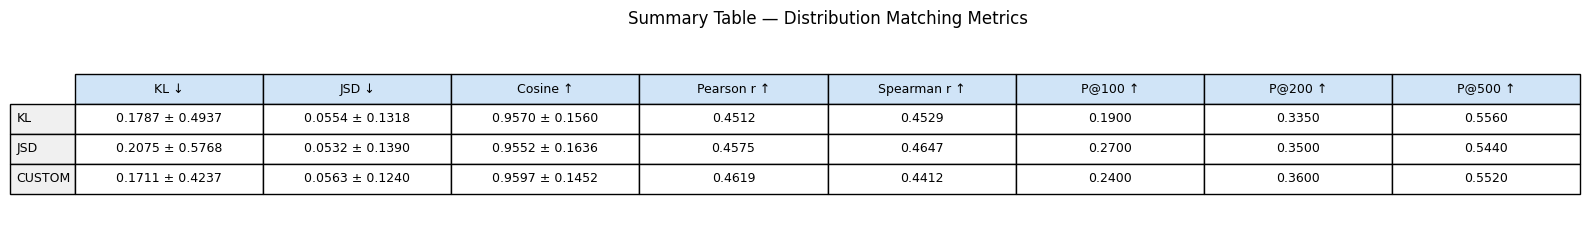

Table image saved to: /content/drive/MyDrive/cifar10h_project/results/summary_table.png


In [10]:
# CELL 8 — Summary table (required by assignment)
table_rows = []
for loss_name in ['kl', 'jsd', 'custom']:
    r = results[loss_name]
    table_rows.append({
        'Loss Function'  : loss_name.upper(),
        'KL ↓'           : f"{r['KL mean']:.4f} ± {r['KL std']:.4f}",
        'JSD ↓'          : f"{r['JSD mean']:.4f} ± {r['JSD std']:.4f}",
        'Cosine ↑'       : f"{r['Cos mean']:.4f} ± {r['Cos std']:.4f}",
        'Pearson r ↑'    : f"{r['Pearson r']:.4f}",
        'Spearman r ↑'   : f"{r['Spearman r']:.4f}",
        'P@100 ↑'        : f"{r['P@100']:.4f}",
        'P@200 ↑'        : f"{r['P@200']:.4f}",
        'P@500 ↑'        : f"{r['P@500']:.4f}",
    })

df = pd.DataFrame(table_rows).set_index('Loss Function')

print("SUMMARY TABLE — All metrics across all loss functions")
print("↓ = lower is better    ↑ = higher is better")
print(df.to_string())

csv_path = os.path.join(RESULTS_DIR, 'summary_table.csv')
df.to_csv(csv_path)
print(f"\nSaved to: {csv_path}")

fig, ax = plt.subplots(figsize=(16, 2.5))
ax.axis('off')
tbl = ax.table(
    cellText  = df.values,
    rowLabels = df.index,
    colLabels = df.columns,
    cellLoc   = 'center',
    loc       = 'center'
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1, 1.8)

for j in range(len(df.columns)):
    tbl[(0, j)].set_facecolor('#d0e4f7')
for i in range(len(df)):
    tbl[(i+1, -1)].set_facecolor('#f0f0f0')

plt.title('Summary Table — Distribution Matching Metrics', fontsize=12, pad=10)
plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'summary_table.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Table image saved to: {save_path}")

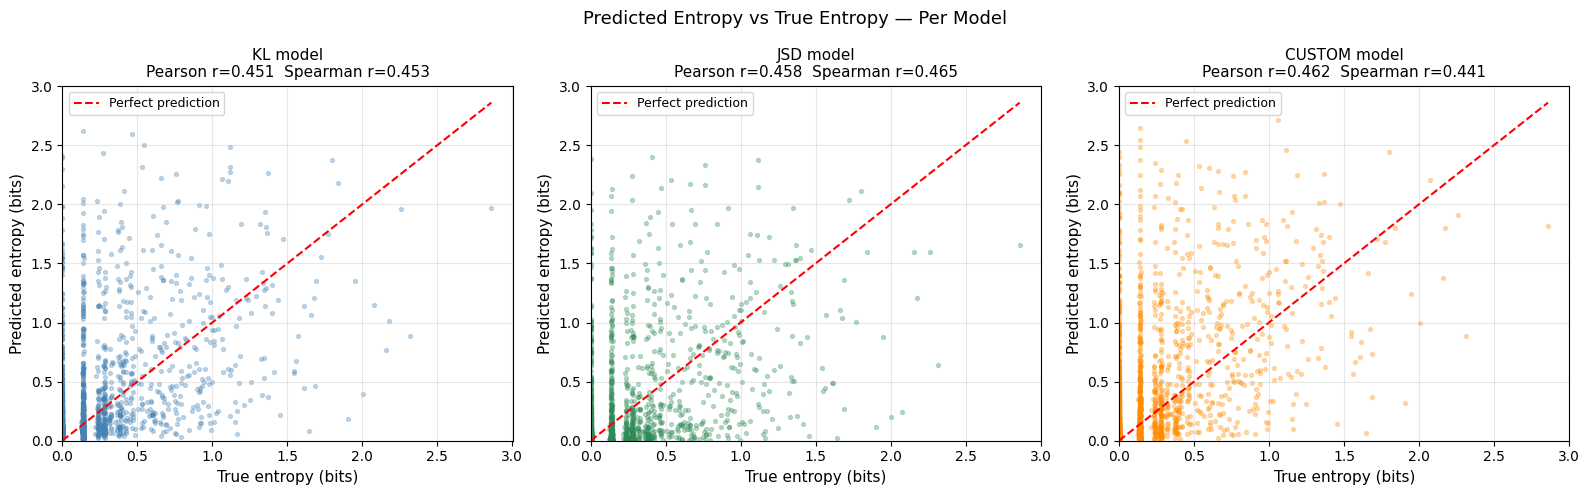

Saved to: /content/drive/MyDrive/cifar10h_project/results/viz_entropy_scatter.png


In [11]:
# CELL 9 — Required Viz: Scatter plot predicted vs true entropy

# X axis = true entropy (from human annotations)
# Y axis = predicted entropy (from the model)
# A perfect model would have all dots on the diagonal line.


fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Predicted Entropy vs True Entropy — Per Model',
             fontsize=13)

model_colors = {'kl': 'steelblue', 'jsd': 'seagreen', 'custom': 'darkorange'}

for ax, loss_name in zip(axes, ['kl', 'jsd', 'custom']):
    r        = results[loss_name]
    pred_ent = r['pred_entropy']

    ax.scatter(true_entropy, pred_ent,
               alpha=0.3, s=8,
               color=model_colors[loss_name])

    max_val = max(true_entropy.max(), pred_ent.max())
    ax.plot([0, max_val], [0, max_val],
            'r--', linewidth=1.5, label='Perfect prediction')

    ax.set_title(
        f"{loss_name.upper()} model\n"
        f"Pearson r={r['Pearson r']:.3f}  "
        f"Spearman r={r['Spearman r']:.3f}",
        fontsize=11
    )
    ax.set_xlabel('True entropy (bits)', fontsize=11)
    ax.set_ylabel('Predicted entropy (bits)', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

    lim = max_val * 1.05
    ax.set_xlim(0, lim)
    ax.set_ylim(0, lim)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'viz_entropy_scatter.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

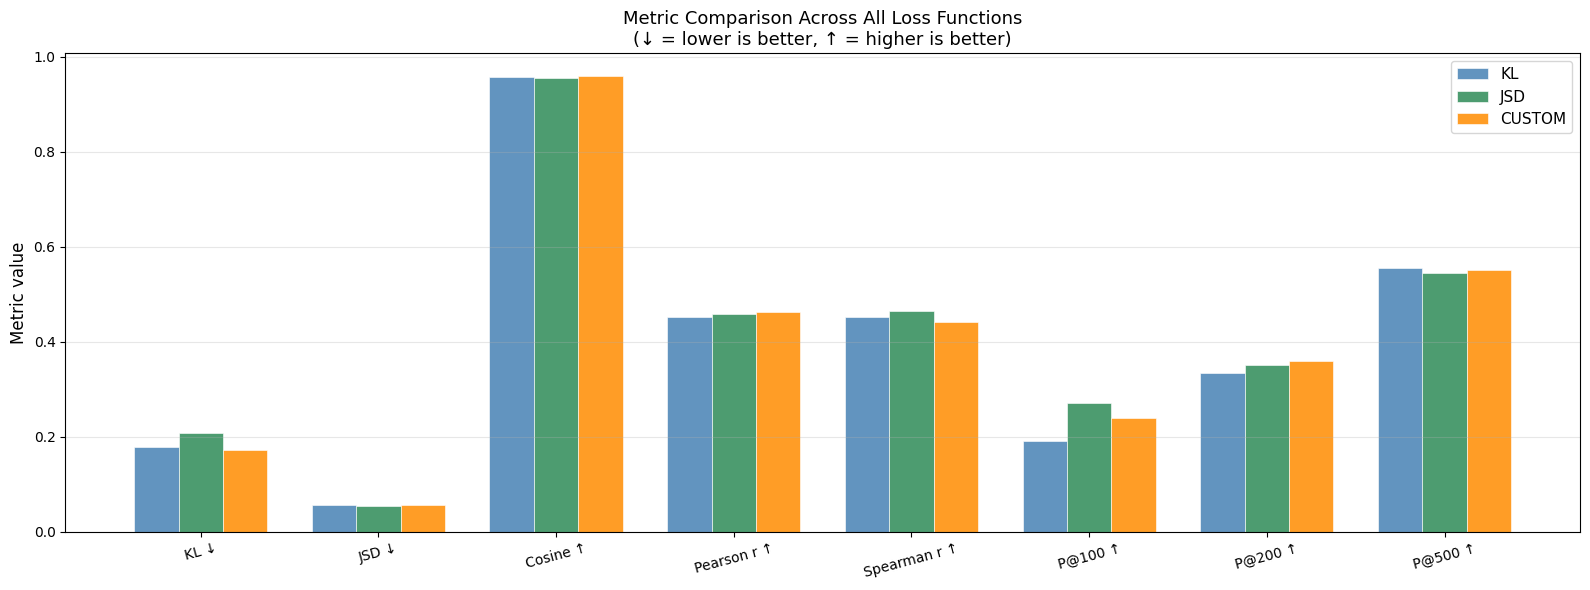

Saved to: /content/drive/MyDrive/cifar10h_project/results/viz_grouped_comparison.png


In [12]:
# CELL 10 — Required Viz: Grouped comparison bar chart

metrics_to_plot = {
    'KL ↓'        : 'KL mean',
    'JSD ↓'       : 'JSD mean',
    'Cosine ↑'    : 'Cos mean',
    'Pearson r ↑' : 'Pearson r',
    'Spearman r ↑': 'Spearman r',
    'P@100 ↑'     : 'P@100',
    'P@200 ↑'     : 'P@200',
    'P@500 ↑'     : 'P@500',
}

loss_names  = ['kl', 'jsd', 'custom']
x           = np.arange(len(metrics_to_plot))
width       = 0.25
bar_colors  = ['steelblue', 'seagreen', 'darkorange']

fig, ax = plt.subplots(figsize=(16, 6))

for i, (loss_name, color) in enumerate(zip(loss_names, bar_colors)):
    values = [results[loss_name][key] for key in metrics_to_plot.values()]
    bars   = ax.bar(x + i * width, values,
                    width, label=loss_name.upper(),
                    color=color, edgecolor='white',
                    linewidth=0.5, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels(list(metrics_to_plot.keys()), fontsize=10, rotation=15)
ax.set_ylabel('Metric value', fontsize=12)
ax.set_title('Metric Comparison Across All Loss Functions\n'
             '(↓ = lower is better, ↑ = higher is better)',
             fontsize=13)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'viz_grouped_comparison.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

Best model by KL: CUSTOM


/tmp/ipykernel_4091/1698349269.py:72: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


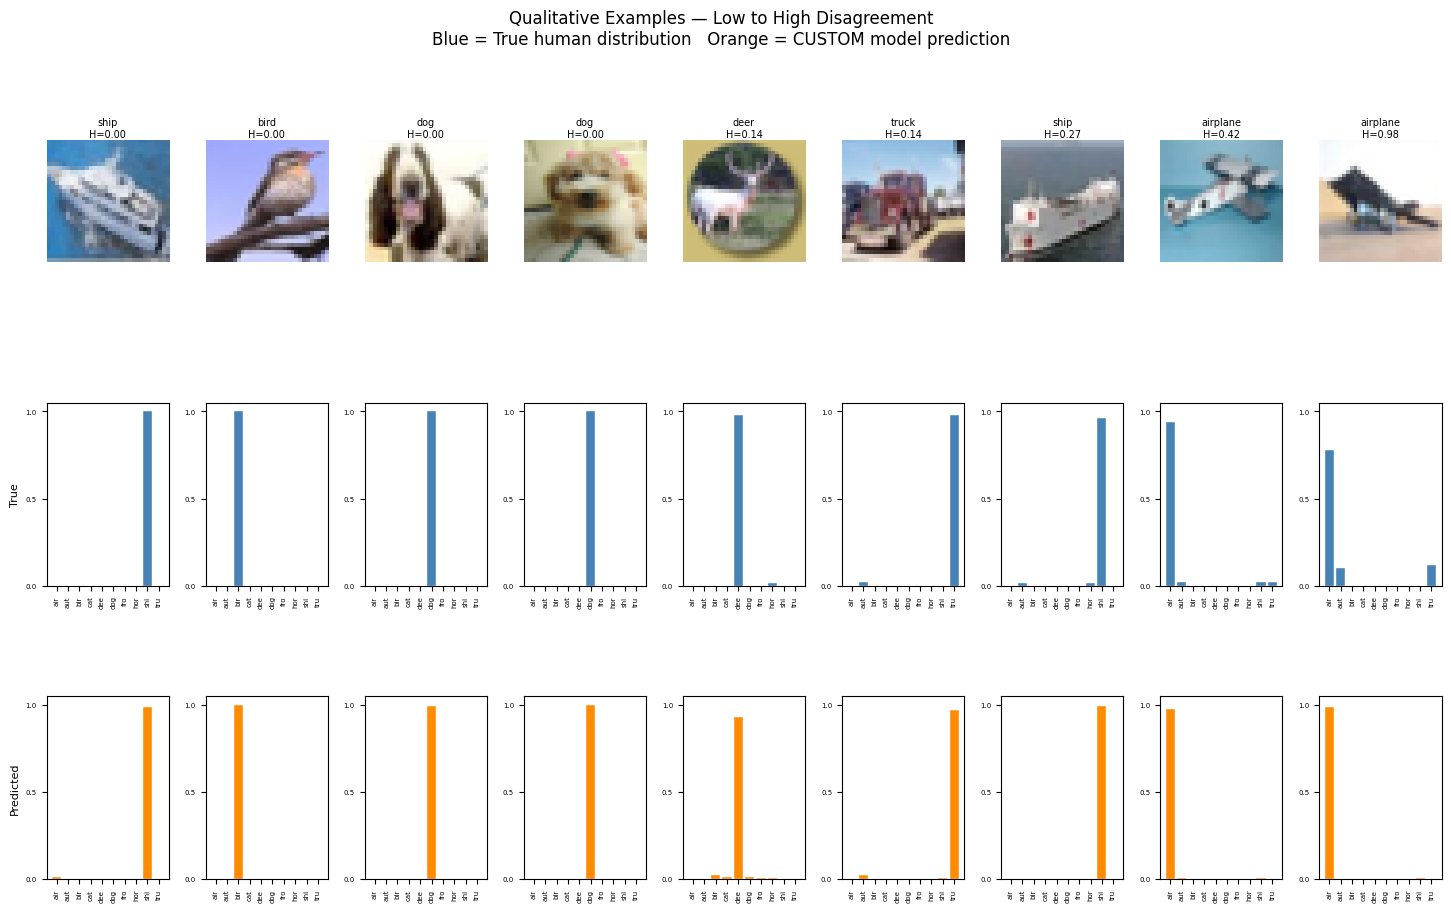

Saved to: /content/drive/MyDrive/cifar10h_project/results/viz_qualitative_examples.png


In [13]:
# CELL 11 — Required Viz: Qualitative examples
# Shows 9 test images spread from low to high entropy.
# For each image: the image itself, the true human distribution,
# and the best model's predicted distribution.
# This directly illustrates whether the model captures ambiguity.
# We use the KL model as "best model" — swap to whichever

raw_test = torchvision.datasets.CIFAR10(
    root=CIFAR10_DIR, train=False,
    download=False, transform=transforms.ToTensor()
)

best_model_name = min(
    ['kl', 'jsd', 'custom'],
    key=lambda n: results[n]['KL mean']
)
best_preds = all_predictions[best_model_name]
print(f"Best model by KL: {best_model_name.upper()}")

n_examples     = 9
percentiles    = np.linspace(5, 95, n_examples)
sorted_indices = np.argsort(true_entropy)
example_positions = [int(p / 100 * len(sorted_indices))
                     for p in percentiles]
example_local_idx = [sorted_indices[pos] for pos in example_positions]

fig = plt.figure(figsize=(18, 10))
fig.suptitle(
    f'Qualitative Examples — Low to High Disagreement\n'
    f'Blue = True human distribution   Orange = {best_model_name.upper()} model prediction',
    fontsize=12
)

gs = gridspec.GridSpec(3, n_examples, figure=fig, hspace=0.6, wspace=0.3)

for col, local_idx in enumerate(example_local_idx):
    actual_idx = test_indices[local_idx]

    ax_img = fig.add_subplot(gs[0, col])
    raw_img, hard_lbl = raw_test[actual_idx]
    ax_img.imshow(np.transpose(raw_img.numpy(), (1, 2, 0)))
    ax_img.axis('off')
    ax_img.set_title(
        f'{CLASS_NAMES[hard_lbl]}\nH={true_entropy[local_idx]:.2f}',
        fontsize=7, pad=2
    )

    ax_true = fig.add_subplot(gs[1, col])
    ax_true.bar(range(10), true_soft[local_idx],
                color='steelblue', edgecolor='white', linewidth=0.3)
    ax_true.set_ylim(0, 1.05)
    ax_true.set_xticks(range(10))
    ax_true.set_xticklabels([c[:3] for c in CLASS_NAMES],
                             rotation=90, fontsize=5)
    ax_true.set_yticks([0, 0.5, 1.0])
    ax_true.tick_params(axis='y', labelsize=5)
    if col == 0:
        ax_true.set_ylabel('True', fontsize=8)

    ax_pred = fig.add_subplot(gs[2, col])
    ax_pred.bar(range(10), best_preds[local_idx],
                color='darkorange', edgecolor='white', linewidth=0.3)
    ax_pred.set_ylim(0, 1.05)
    ax_pred.set_xticks(range(10))
    ax_pred.set_xticklabels([c[:3] for c in CLASS_NAMES],
                             rotation=90, fontsize=5)
    ax_pred.set_yticks([0, 0.5, 1.0])
    ax_pred.tick_params(axis='y', labelsize=5)
    if col == 0:
        ax_pred.set_ylabel('Predicted', fontsize=8)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'viz_qualitative_examples.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

   10 annotators — KL: 0.2059  JSD: 0.0661
   20 annotators — KL: 0.1931  JSD: 0.0622
   30 annotators — KL: 0.1840  JSD: 0.0606
   50 annotators — KL: 0.1711  JSD: 0.0563


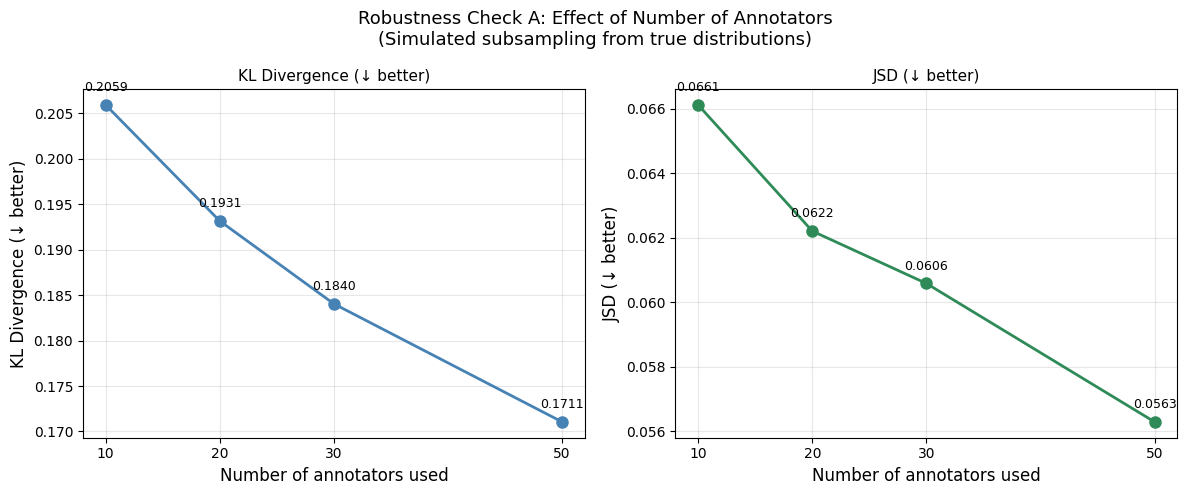

Saved to: /content/drive/MyDrive/cifar10h_project/results/robustness_annotator_subsampling.png


In [14]:
# CELL 12 — Robustness Check A: Annotator Subsampling

# Full CIFAR-10H has ~51 annotators per image.
# What if we only had 10 or 20 annotators?
# The soft labels become noisier — less reliable.
#
# This check: does our model's KL divergence get worse
# as we use fewer annotators to define the "true" distribution?

ANNOTATOR_COUNTS = [10, 20, 30, 50]
best_preds_full = all_predictions[best_model_name]

subsample_kl  = []
subsample_jsd = []

for n_ann in ANNOTATOR_COUNTS:
    kl_scores  = []
    jsd_scores = []

    for i in range(len(test_indices)):
        true_dist = true_soft[i]

        if n_ann >= 50:
            noisy_dist = true_dist
        else:

            true_dist_norm = true_dist.astype(np.float64)
            true_dist_norm = true_dist_norm / true_dist_norm.sum()
            votes          = np.random.multinomial(n_ann, true_dist_norm)
            noisy_dist     = votes.astype(np.float32) / n_ann





        kl_scores.append(
            compute_kl_per_image(
                noisy_dist[np.newaxis, :],
                best_preds_full[i][np.newaxis, :]
            )[0]
        )
        jsd_scores.append(
            compute_jsd_per_image(
                noisy_dist[np.newaxis, :],
                best_preds_full[i][np.newaxis, :]
            )[0]
        )

    subsample_kl.append(np.mean(kl_scores))
    subsample_jsd.append(np.mean(jsd_scores))
    print(f"  {n_ann:>3} annotators — KL: {np.mean(kl_scores):.4f}  "
          f"JSD: {np.mean(jsd_scores):.4f}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Robustness Check A: Effect of Number of Annotators\n'
             '(Simulated subsampling from true distributions)', fontsize=13)

for ax, values, metric, color in zip(
    axes,
    [subsample_kl, subsample_jsd],
    ['KL Divergence (↓ better)', 'JSD (↓ better)'],
    ['steelblue', 'seagreen']
):
    ax.plot(ANNOTATOR_COUNTS, values, 'o-',
            color=color, linewidth=2, markersize=8)
    ax.set_xlabel('Number of annotators used', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)
    ax.set_title(metric, fontsize=11)
    ax.set_xticks(ANNOTATOR_COUNTS)
    ax.grid(alpha=0.3)

    for x, y in zip(ANNOTATOR_COUNTS, values):
        ax.annotate(f'{y:.4f}', (x, y),
                    textcoords="offset points",
                    xytext=(0, 10), ha='center', fontsize=9)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'robustness_annotator_subsampling.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

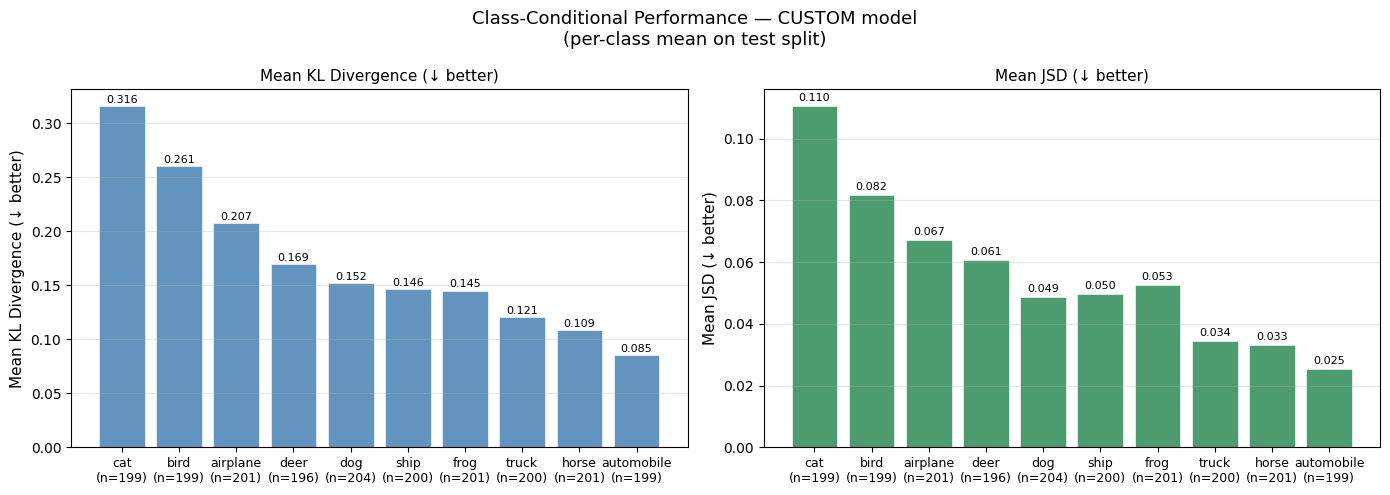

Saved to: /content/drive/MyDrive/cifar10h_project/results/robustness_class_conditional.png


In [15]:
# CELL 13 — Robustness Check C: Class-conditional performance
# Does the model predict disagreement equally well for all classes?
# Or does it struggle more for some classes than others?
#
# For each class, we take the test images whose HARD label is
# that class and compute the mean KL and JSD for those images.
#
# Expected: classes with higher average entropy (cat, dog)
# should be harder to model accurately.


hard_labels_test = np.argmax(true_soft, axis=1)

class_kl  = []
class_jsd = []
class_n   = []

for class_idx in range(10):
    mask      = (hard_labels_test == class_idx)
    n_images  = mask.sum()
    class_n.append(n_images)

    if n_images == 0:
        class_kl.append(0)
        class_jsd.append(0)
        continue

    kl_vals  = compute_kl_per_image(
        true_soft[mask], best_preds_full[mask]
    )
    jsd_vals = compute_jsd_per_image(
        true_soft[mask], best_preds_full[mask]
    )
    class_kl.append(kl_vals.mean())
    class_jsd.append(jsd_vals.mean())

sorted_order = np.argsort(class_kl)[::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Class-Conditional Performance — {best_model_name.upper()} model\n'
             '(per-class mean on test split)', fontsize=13)

for ax, values, metric, color in zip(
    axes,
    [class_kl, class_jsd],
    ['Mean KL Divergence (↓ better)', 'Mean JSD (↓ better)'],
    ['steelblue', 'seagreen']
):
    sorted_vals   = [values[i] for i in sorted_order]
    sorted_names  = [CLASS_NAMES[i] for i in sorted_order]
    sorted_counts = [class_n[i] for i in sorted_order]

    bars = ax.bar(range(10), sorted_vals,
                  color=color, edgecolor='white',
                  linewidth=0.5, alpha=0.85)
    ax.set_xticks(range(10))
    ax.set_xticklabels(
        [f'{n}\n(n={c})' for n, c in zip(sorted_names, sorted_counts)],
        fontsize=9
    )
    ax.set_ylabel(metric, fontsize=11)
    ax.set_title(metric, fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    for bar, val in zip(bars, sorted_vals):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.001,
                f'{val:.3f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
save_path = os.path.join(RESULTS_DIR, 'robustness_class_conditional.png')
plt.savefig(save_path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved to: {save_path}")

In [16]:
# CELL 14 — Final


print("NB3 COMPLETE — FILE CHECKLIST")

files_to_check = {
    "Summary table CSV"          : os.path.join(RESULTS_DIR, 'summary_table.csv'),
    "Summary table PNG"          : os.path.join(RESULTS_DIR, 'summary_table.png'),
    "Entropy scatter plot"       : os.path.join(RESULTS_DIR, 'viz_entropy_scatter.png'),
    "Grouped comparison chart"   : os.path.join(RESULTS_DIR, 'viz_grouped_comparison.png'),
    "Qualitative examples"       : os.path.join(RESULTS_DIR, 'viz_qualitative_examples.png'),
    "Robustness: subsampling"    : os.path.join(RESULTS_DIR, 'robustness_annotator_subsampling.png'),
    "Robustness: class-wise"     : os.path.join(RESULTS_DIR, 'robustness_class_conditional.png'),
}

all_ok = True
for name, path in files_to_check.items():
    exists = os.path.exists(path)
    size   = f"({os.path.getsize(path)/1024:.0f} KB)" if exists else ""
    print(f"  {'OK' if exists else 'MISSING':<8} {name:<35} {size}")
    if not exists:
        all_ok = False

if all_ok:
    print("NB3 complete. All evaluation outputs saved to Drive.")
    print("Hand results/ folder to your teammate for NB4.")
else:
    print("Some files missing — rerun the relevant cells.")

# Print final summary
print("\nFinal metric summary (best model highlighted):")
best = min(['kl', 'jsd', 'custom'], key=lambda n: results[n]['KL mean'])
for loss_name in ['kl', 'jsd', 'custom']:
    marker = " ← BEST" if loss_name == best else ""
    print(f"  {loss_name.upper():<8} KL={results[loss_name]['KL mean']:.4f}  "
          f"Spearman r={results[loss_name]['Spearman r']:.4f}{marker}")

NB3 COMPLETE — FILE CHECKLIST
  OK       Summary table CSV                   (0 KB)
  OK       Summary table PNG                   (53 KB)
  OK       Entropy scatter plot                (239 KB)
  OK       Grouped comparison chart            (66 KB)
  OK       Qualitative examples                (96 KB)
  OK       Robustness: subsampling             (121 KB)
  OK       Robustness: class-wise              (100 KB)
NB3 complete. All evaluation outputs saved to Drive.
Hand results/ folder to your teammate for NB4.

Final metric summary (best model highlighted):
  KL       KL=0.1787  Spearman r=0.4529
  JSD      KL=0.2075  Spearman r=0.4647
  CUSTOM   KL=0.1711  Spearman r=0.4412 ← BEST
